# 💼 AI Job Role Prediction

End-to-end ML workflow using the Kaggle Candidate Job Role Dataset.

**Workflow:** Load data → EDA → preprocessing → TF-IDF → Logistic Regression → evaluation → custom prediction → save model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

## 1. Load Dataset

Put the Kaggle CSV in the same folder as this notebook.

In [2]:
CSV_FILE = 'candidate_job_role_dataset.csv'
df = pd.read_csv(CSV_FILE)

print('Shape:', df.shape)
df.head()

Shape: (1000, 5)


,candidate_id,skills,qualification,experience_level,job_role
0,1,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer


In [3]:
print('Columns:')
print(df.columns.tolist())

print('\nMissing values:')
print(df.isnull().sum())

print('\nData types:')
df.info()

Columns:
['candidate_id', 'skills', 'qualification', 'experience_level', 'job_role']

Missing values:
candidate_id        0
skills              0
qualification       0
experience_level    0
job_role            0
dtype: int64

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   candidate_id      1000 non-null   int64 
 1   skills            1000 non-null   object
 2   qualification     1000 non-null   object
 3   experience_level  1000 non-null   object
 4   job_role          1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB


## 2. Explore Job Roles

In [4]:
df['job_role'].value_counts()

job_role
Mobile Developer                  75
Data Scientist                    50
Marketing                         50
Data Analyst                      50
Software Project Manager          50
Cybersecurity Engineer            50
PHP Developer                     50
C# Developer                      50
Frontend Developer                50
HR                                50
Blockchain Developer              50
Full Stack Java Developer         50
DevOps Engineer                   50
Game Developer                    50
Full Stack Python Developer       50
Designer                          50
Backend Developer                 50
Kubernetes Operations Engineer    49
Web Developer                     49
AIML                              25
Finance                            1
Video Game Designer                1
Name: count, dtype: int64

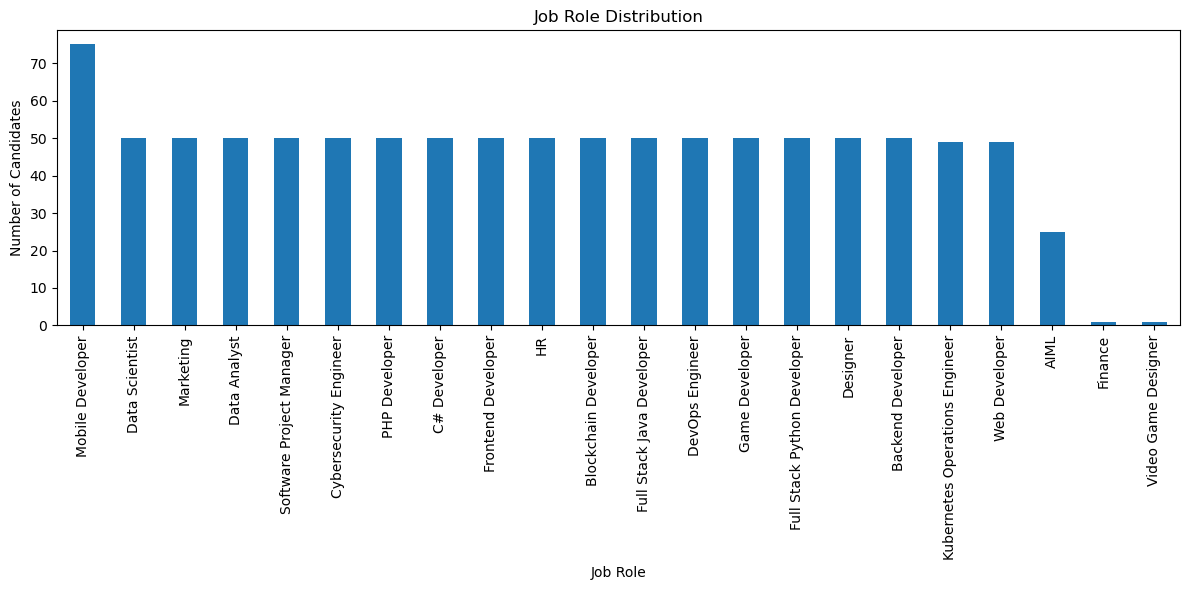

In [5]:
plt.figure(figsize=(12, 6))
df['job_role'].value_counts().plot(kind='bar')
plt.title('Job Role Distribution')
plt.xlabel('Job Role')
plt.ylabel('Number of Candidates')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3. Prepare Data

In [9]:
required_columns = ['skills', 'qualification', 'experience_level', 'job_role']
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f'Missing columns: {missing_columns}. Check the CSV column names.')

df = df[required_columns].copy()
df = df.dropna()

for col in ['skills', 'qualification', 'experience_level']:
    df[col] = df[col].astype(str)

df['combined_features'] = (
    df['skills'] + ' ' +
    df['qualification'] + ' ' +
    df['experience_level']
)

df[['skills', 'qualification', 'experience_level', 'job_role', 'combined_features']].head()

,skills,qualification,experience_level,job_role,combined_features
0,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist,"Python, SQL, TensorFlow, Machine Learning, Com..."
1,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer,"HTML, CSS, JavaScript, React, Teamwork Bachelo..."
2,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer,"Java, Spring, SQL, REST APIs, Problem Solving ..."
3,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer,"Figma, Adobe XD, UI/UX Design, Creativity Bach..."
4,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer,"Python, Django, JavaScript, React, Agile Maste..."


## 4. Train-Test Split

In [10]:
# Check job role distribution
role_counts = df["job_role"].value_counts()

print(role_counts)

# Remove job roles having fewer than 2 samples
valid_roles = role_counts[role_counts >= 2].index

df = df[df["job_role"].isin(valid_roles)].copy()

print("\nAfter removing rare roles:")
print(df["job_role"].value_counts())

# Features and target
X = df["combined_features"]
y = df["job_role"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

job_role
Mobile Developer                  75
Data Scientist                    50
Marketing                         50
Data Analyst                      50
Software Project Manager          50
Cybersecurity Engineer            50
PHP Developer                     50
C# Developer                      50
Frontend Developer                50
HR                                50
Blockchain Developer              50
Full Stack Java Developer         50
DevOps Engineer                   50
Game Developer                    50
Full Stack Python Developer       50
Designer                          50
Backend Developer                 50
Kubernetes Operations Engineer    49
Web Developer                     49
AIML                              25
Finance                            1
Video Game Designer                1
Name: count, dtype: int64

After removing rare roles:
job_role
Mobile Developer                  75
Data Scientist                    50
Marketing                         50
Dat

## 5. TF-IDF Feature Extraction

In [11]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Training TF-IDF shape:', X_train_tfidf.shape)
print('Testing TF-IDF shape:', X_test_tfidf.shape)

Training TF-IDF shape: (798, 447)
Testing TF-IDF shape: (200, 447)


## 6. Train Logistic Regression

In [12]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9900

Classification Report:

                                precision    recall  f1-score   support

                          AIML       1.00      1.00      1.00         5
             Backend Developer       0.91      1.00      0.95        10
          Blockchain Developer       1.00      1.00      1.00        10
                  C# Developer       1.00      1.00      1.00        10
        Cybersecurity Engineer       1.00      1.00      1.00        10
                  Data Analyst       1.00      1.00      1.00        10
                Data Scientist       1.00      1.00      1.00        10
                      Designer       1.00      1.00      1.00        10
               DevOps Engineer       1.00      0.90      0.95        10
            Frontend Developer       1.00      1.00      1.00        10
     Full Stack Java Developer       1.00      0.90      0.95        10
   Full Stack Python Developer       1.00      1.00      1.00        10
                Game 

## 7. Confusion Matrix

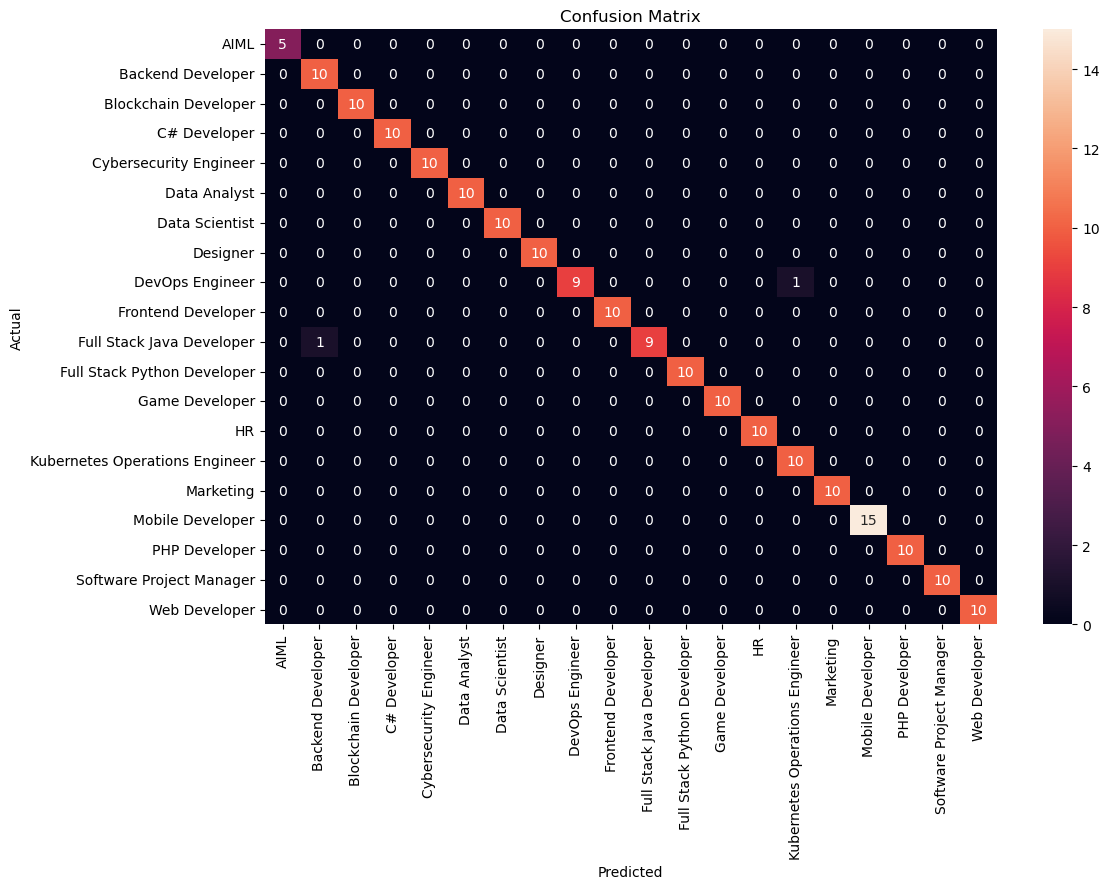

In [13]:
labels = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Test a Custom Candidate

In [14]:
skills = 'Python, Pandas, NumPy, SQL, Machine Learning, Scikit-learn'
qualification = "Bachelor's"
experience = 'Entry'

candidate_text = f'{skills} {qualification} {experience}'
candidate_vector = vectorizer.transform([candidate_text])

prediction = model.predict(candidate_vector)[0]
print('Predicted Job Role:', prediction)

Predicted Job Role: Data Scientist


In [15]:
probabilities = model.predict_proba(candidate_vector)[0]

result = pd.DataFrame({
    'Job Role': model.classes_,
    'Probability': probabilities
}).sort_values('Probability', ascending=False)

result.head(5)

,Job Role,Probability
6,Data Scientist,0.226352
5,Data Analyst,0.175784
11,Full Stack Python Developer,0.058121
16,Mobile Developer,0.045635
7,Designer,0.039371


## 9. Save Model and Vectorizer

These files will be loaded by the Streamlit app.

In [16]:
with open('job_role_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print('Saved: job_role_model.pkl')
print('Saved: tfidf_vectorizer.pkl')

Saved: job_role_model.pkl
Saved: tfidf_vectorizer.pkl
